# Underwater Fish Segmentation
## Architecture: VAE (ConvNeXt-Small Encoder) + Self-Attention Bridge + U-Net Decoder with Attention Gates
### **v3 Changes**: ResNet-50 → ConvNeXt-Small · Plain Skip Connections → Attention Gates
### Fish4Knowledge Dataset — 23 Categories

```
Input Image (3×256×256)
        │
  ConvNeXt-Small Encoder  ←── pretrained ImageNet
   s0(96) s1(192) s2(384) s3(768)
        │
  Bottleneck (768, 8×8)
        │
  ┌─────┴──────┐
  μ (512)    log_σ² (512)   ←── VAE latent space
  └─────┬──────┘
        │  reparameterise
        z_vae (512, 8×8)
        │
  Self-Attention Bridge    ←── 3 × Multi-Head SA layers
        │
  U-Net Decoder + Attention Gates  ←── gates replace plain skip connections
        │
  Segmentation Mask (1×256×256)
```

**Why ConvNeXt + Attention Gates?**
- ConvNeXt uses large 7×7 depthwise convolutions, LayerNorm, and GELU → stronger features than ResNet
- Attention Gates suppress irrelevant activations in skip connections before concatenation
- Gates learn *where* to attend per decoder scale, improving boundary precision
- Both changes are drop-in; the VAE bridge and training loop are unchanged


## 1. Install & Environment Fix

> **Run Cell 1 once, then use Kernel → Restart, then run from Cell 2 onwards.**
> This is required because numpy ABI changes only take effect after a kernel restart.

In [1]:
import os, subprocess, sys

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

def pip(*args):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-500:] if r.stdout else '')
        print(r.stderr[-500:] if r.stderr else '')
        raise RuntimeError(f'pip failed: {args}')

# ── 1. Force-install a single numpy version that everything agrees on ──
# numpy 1.26.x is the last series before the ABI break in 2.0.
# sklearn, scipy, and pandas wheels on PyPI are all built against 1.26.
print('[1/4] Pinning numpy 1.26 ...')
pip('numpy==1.26.4', '--force-reinstall', '--no-deps')

# ── 2. Reinstall sklearn + scipy + pandas against numpy 1.26 ──────────
print('[2/4] Reinstalling scikit-learn, scipy, pandas ...')
pip('scikit-learn', 'scipy', 'pandas', '--force-reinstall')

# ── 3. PyTorch (only if not present) ─────────────────────────────────
print('[3/4] Checking PyTorch ...')
try:
    import importlib
    torch_spec = importlib.util.find_spec('torch')
    if torch_spec is None:
        raise ModuleNotFoundError
    print('  torch already installed, skipping.')
except ModuleNotFoundError:
    print('  Installing PyTorch 2.4 ...')
    pip('torch==2.4.0+cu121', 'torchvision==0.19.0+cu121',
        '--index-url', 'https://download.pytorch.org/whl/cu121',
        '--force-reinstall', '--no-deps')

# ── 4. Other deps ─────────────────────────────────────────────────────
print('[4/4] Installing other deps ...')
pip('timm', 'opencv-python-headless', 'albumentations', 'matplotlib', 'tqdm')

print()
print('=' * 55)
print('  Installation complete.')
print()
print('  *** RESTART KERNEL NOW ***')
print('  Menu: Kernel -> Restart Kernel  (or Ctrl+F5)')
print('  Then run ALL cells from Cell 2 onwards.')
print('  Do NOT re-run this cell after restarting.')
print('=' * 55)

# Auto-restart kernel so the new numpy .so is loaded fresh
print()
print('Auto-restarting kernel ...')
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(restart=True)


[1/4] Pinning numpy 1.26 ...


[2/4] Reinstalling scikit-learn, scipy, pandas ...
[3/4] Checking PyTorch ...
  torch already installed, skipping.
[4/4] Installing other deps ...

  Installation complete.

  *** RESTART KERNEL NOW ***
  Menu: Kernel -> Restart Kernel  (or Ctrl+F5)
  Then run ALL cells from Cell 2 onwards.
  Do NOT re-run this cell after restarting.

Auto-restarting kernel ...


{'status': 'ok', 'restart': True}

: 

## 2. Imports & Configuration

> Start here after kernel restart. sklearn will import cleanly now.

In [13]:
import os, random, glob, json
from pathlib import Path
from collections import Counter

import numpy as np
print(f'numpy       : {np.__version__}')   # should be 1.26.4

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

# sklearn — safe after kernel restart with numpy 1.26.4
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.decomposition import PCA
print('sklearn     : OK ✓')

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark     = True

torch.cuda.empty_cache()

class Config:
    DATA_ROOT   = None   # auto-discovered below
    IMAGE_SIZE  = 320
    TRAIN_SPLIT = 0.80
    VAL_SPLIT   = 0.10

    BATCH_SIZE   = 24
    EPOCHS       = 45
    LR           = 1e-4
    MIN_LR       = 1e-7
    WEIGHT_DECAY = 1e-4
    GRAD_CLIP    = 1.0

    USE_AMP      = True
    ACCUM_STEPS  = 1
    USE_TTA      = True

    LATENT_DIM   = 512
    KL_WEIGHT    = 1e-7
    KL_WARMUP    = 50

    ATTN_HEADS   = 4
    ATTN_LAYERS  = 2
    FFN_DIM      = 1024
    ATTN_DROPOUT = 0.1

    PATIENCE     = 40
    POS_WEIGHT   = 7.3

    ENC_CHANNELS = [96, 192, 384, 768]   # ConvNeXt-Small

    CHECKPOINT = './checkpoints'
    DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cfg = Config()
os.makedirs(cfg.CHECKPOINT, exist_ok=True)

allocated = torch.cuda.memory_allocated() / 1e9
total     = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'Device      : {cfg.DEVICE}  ({torch.cuda.get_device_name(0)})')
print(f'GPU memory  : {allocated:.2f} / {total:.1f} GB')
print(f'Batch size  : {cfg.BATCH_SIZE}')
print(f'AMP         : {cfg.USE_AMP}')
print(f'Data root   : {cfg.DATA_ROOT}')


numpy       : 2.5.1
sklearn     : OK ✓
Device      : cuda  (Tesla T4)
GPU memory  : 1.40 / 15.6 GB
Batch size  : 24
AMP         : True
Data root   : None


In [14]:
# ── GPU utilisation sanity check ─────────────────────────────────
# Run this after model is built to confirm AMP + batch size are working
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.used,memory.total,utilization.gpu',
                         '--format=csv,noheader'], capture_output=True, text=True)
print('GPU status:', result.stdout.strip())
print(f'AMP enabled : {cfg.USE_AMP}  ← should be True for ~2× speedup on T4')
print(f'Batch size  : {cfg.BATCH_SIZE}  ← T4 16 GB handles batch=16 comfortably')
print(f'cudnn.bench : {torch.backends.cudnn.benchmark}  ← auto-tunes CUDA kernels')


GPU status: Tesla T4, 1957 MiB, 15360 MiB, 0 %
AMP enabled : True  ← should be True for ~2× speedup on T4
Batch size  : 24  ← T4 16 GB handles batch=16 comfortably
cudnn.bench : True  ← auto-tunes CUDA kernels


## 3. Dataset — F4K

**Structure:**
```
F4k/
  imgs/{Standard,ComplexBkg,Crowded,DynamicBkg,Hybrid}/  ← .jpg
  masks/{...}/                                           ← .png, same stem
  test imgs/{...}/
  test masks/{...}/
  Unseen Test Image/   ← 6 held-out .jpg
  Unseen Test Masks/   ← 6 held-out .png
```

### Dataset layout (updated)

This notebook now expects:

```
fish_image/                 <- dataset root (pass via cfg.DATA_ROOT, or let auto-discovery find it)
├── fish_image/              <- images
│   ├── fish_01/
│   │   ├── fish_000000009598_05281.jpg
│   │   └── ...
│   ├── fish_02/
│   └── ... fish_23/
└── mask_image/               <- masks
    ├── mask_01/
    │   ├── mask_000000009598_05281.png
    │   └── ...
    ├── mask_02/
    └── ... mask_23/
```

Pairing logic:
- **Category** = the two-digit number in the folder name (`fish_01` ↔ `mask_01`, ..., `fish_23` ↔ `mask_23`) — 23 fish species, matching the model's per-category evaluation.
- **Image ↔ mask match** = same trailing identifier after the first underscore
  (`fish_000000009598_05281` ↔ `mask_000000009598_05281`), regardless of file extension.
- Since there's no separate test/unseen folder in this layout, the split below is done
  **per category** (stratified) into train/val/test/unseen, so every species is
  represented in every split rather than risking a species being entirely absent
  from training or entirely absent from testing.

In [15]:
from pathlib import Path
from collections import Counter
import re

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


# ── Auto-discover DATA_ROOT ────────────────────────────────────────
# Looks for a folder that contains both 'fish_image/' and 'mask_image/'.
def find_fish_image_root(search_dirs=None):
    candidates = search_dirs or [
        Path('/teamspace/studios/this_studio'),
        Path('/kaggle/input'),
        Path('/content'),
        Path.home(),
    ]
    for base in candidates:
        if not base.exists():
            continue
        if (base / 'fish_image').exists() and (base / 'mask_image').exists():
            return base
        for child in sorted(base.iterdir()):
            if not child.is_dir():
                continue
            if (child / 'fish_image').exists() and (child / 'mask_image').exists():
                return child
            for grandchild in sorted(child.iterdir()):
                if not grandchild.is_dir():
                    continue
                if (grandchild / 'fish_image').exists() and (grandchild / 'mask_image').exists():
                    return grandchild
    return None


if cfg.DATA_ROOT is None:
    discovered = find_fish_image_root()
    if discovered is None:
        raise FileNotFoundError(
            "Could not find dataset. Make sure 'fish_image/' and 'mask_image/' "
            "folders are present under the dataset root (set cfg.DATA_ROOT manually "
            "if it's somewhere auto-discovery doesn't look).")
    cfg.DATA_ROOT = str(discovered)

ROOT         = Path(cfg.DATA_ROOT)
IMAGES_ROOT  = ROOT / 'fish_image'
MASKS_ROOT   = ROOT / 'mask_image'
print(f'Dataset root : {ROOT}')
print(f'fish_image   : {IMAGES_ROOT.exists()}')
print(f'mask_image   : {MASKS_ROOT.exists()}')


# ── Match category folders: fish_01 <-> mask_01, ..., fish_23 <-> mask_23 ──
def _category_number(folder_name):
    m = re.search(r'(\d+)$', folder_name)
    return m.group(1) if m else None

img_cat_dirs  = {d.name: d for d in sorted(IMAGES_ROOT.iterdir()) if d.is_dir() and d.name.startswith('fish_')}
mask_cat_dirs = {d.name: d for d in sorted(MASKS_ROOT.iterdir())  if d.is_dir() and d.name.startswith('mask_')}

cat_pairs = {}
for name, img_dir in img_cat_dirs.items():
    num = _category_number(name)
    mask_name = f'mask_{num}'
    if mask_name in mask_cat_dirs:
        cat_pairs[num] = (img_dir, mask_cat_dirs[mask_name])
    else:
        print(f'  [WARN] no matching mask folder for {name}')

print(f'\nMatched {len(cat_pairs)} category folders (expected 23)')


# ── Pair images and masks within a category by shared filename suffix ──
# e.g. fish_000000009598_05281.jpg <-> mask_000000009598_05281.png
def _pair_category(img_dir: Path, mask_dir: Path, category: str, verbose=True):
    pairs, missing = [], []
    mask_by_suffix = {}
    for mask_p in mask_dir.iterdir():
        if mask_p.suffix.lower() not in IMG_EXTS:
            continue
        suffix = mask_p.stem.split('_', 1)[1] if '_' in mask_p.stem else mask_p.stem
        mask_by_suffix[suffix] = mask_p

    for img_p in sorted(img_dir.iterdir()):
        if img_p.suffix.lower() not in IMG_EXTS:
            continue
        suffix = img_p.stem.split('_', 1)[1] if '_' in img_p.stem else img_p.stem
        mask_p = mask_by_suffix.get(suffix)
        if mask_p is not None:
            pairs.append((str(img_p), str(mask_p), category))
        else:
            missing.append(img_p.name)

    if missing and verbose:
        print(f'  [WARN] {category}: {len(missing)} images have no mask '
              f'(e.g. {missing[0]})')
    return pairs


CATEGORIES = sorted(cat_pairs.keys(), key=lambda n: int(n))
SUBSETS    = [f'fish_{n}' for n in CATEGORIES]   # 23 species; kept as SUBSETS for
                                                   # compatibility with per-category
                                                   # evaluation cells further down

all_samples = []
print('\nPairing images and masks per category:')
for num in CATEGORIES:
    img_dir, mask_dir = cat_pairs[num]
    pairs = _pair_category(img_dir, mask_dir, f'fish_{num}')
    print(f'  fish_{num:>2s}: {len(pairs):5d}')
    all_samples.extend(pairs)

print(f'\nTotal pairs: {len(all_samples)}')

if len(all_samples) == 0:
    raise RuntimeError(
        'No image/mask pairs found. Check that filenames share a common suffix '
        'after the first underscore, and that extensions are in IMG_EXTS.')


# ── Stratified split per category: train / val / test / unseen ──────
# Stratifying per species means every species appears in every split, instead of
# risking a species being entirely absent from training or from testing.
TEST_SPLIT   = 0.08
UNSEEN_SPLIT = 0.02
assert cfg.TRAIN_SPLIT + cfg.VAL_SPLIT + TEST_SPLIT + UNSEEN_SPLIT <= 1.0 + 1e-6

by_cat = {}
for s in all_samples:
    by_cat.setdefault(s[2], []).append(s)

train_samples, val_samples, test_samples, unseen_samples = [], [], [], []

for cat, items in by_cat.items():
    items = items[:]  # copy before shuffling
    random.shuffle(items)
    n = len(items)
    n_train = int(n * cfg.TRAIN_SPLIT)
    n_val   = int(n * cfg.VAL_SPLIT)
    n_test  = int(n * TEST_SPLIT)
    train_samples.extend(items[:n_train])
    val_samples.extend(items[n_train:n_train + n_val])
    test_samples.extend(items[n_train + n_val:n_train + n_val + n_test])
    unseen_samples.extend(items[n_train + n_val + n_test:])

random.shuffle(train_samples)
random.shuffle(val_samples)
random.shuffle(test_samples)
random.shuffle(unseen_samples)

print()
print('=' * 52)
print(f'  Train   : {len(train_samples):5d} pairs')
print(f'  Val     : {len(val_samples):5d} pairs')
print(f'  Test    : {len(test_samples):5d} pairs')
print(f'  Unseen  : {len(unseen_samples):5d} pairs')
print('=' * 52)

print('\nCategory distribution (train+val):')
counts = Counter(s[2] for s in train_samples + val_samples)
for cat in SUBSETS:
    cnt = counts.get(cat, 0)
    denom = max(1, len(train_samples) + len(val_samples))
    pct = cnt / denom * 100
    bar = '█' * int(pct / 2)
    print(f'  {cat:10s}: {cnt:5d}  ({pct:5.1f}%)  {bar}')

# Quick sanity: verify first pair is readable
img_p, mask_p, _ = train_samples[0]
_img  = cv2.imread(img_p)
_mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
assert _img  is not None, f'Cannot read image: {img_p}'
assert _mask is not None, f'Cannot read mask:  {mask_p}'
print(f'\nSanity check: img={_img.shape}  mask={_mask.shape}  ✓')
print(f'  img  : {img_p}')
print(f'  mask : {mask_p}')

Dataset root : /teamspace/studios/this_studio/Fish_recognition_GT
fish_image   : True
mask_image   : True

Matched 23 category folders (expected 23)

Pairing images and masks per category:
  fish_01: 12112
  fish_02:  2683
  fish_03:  3593
  fish_04:  4049
  fish_05:  2534
  fish_06:   190
  fish_07:   450
  fish_08:   218
  fish_09:   241
  fish_10:   299
  fish_11:    98
  fish_12:   147
  fish_13:   181
  fish_14:    90
  fish_15:    42
  fish_16:   206
  fish_17:    49
  fish_18:    56
  fish_19:    29
  fish_20:    21
  fish_21:    16
  fish_22:    41
  fish_23:    25

Total pairs: 27370

  Train   : 21886 pairs
  Val     :  2727 pairs
  Test    :  2178 pairs
  Unseen  :   579 pairs

Category distribution (train+val):
  fish_01   : 10900  ( 44.3%)  ██████████████████████
  fish_02   :  2414  (  9.8%)  ████
  fish_03   :  3233  ( 13.1%)  ██████
  fish_04   :  3643  ( 14.8%)  ███████
  fish_05   :  2280  (  9.3%)  ████
  fish_06   :   171  (  0.7%)  
  fish_07   :   405  (  1.6%)  


## 4. Augmentation & DataLoaders

In [16]:
# ── Augmentation ─────────────────────────────────────────────────
train_tf = A.Compose([
    A.Resize(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                       rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3,
                               contrast_limit=0.3, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20,
                         sat_shift_limit=30, p=0.4),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.CoarseDropout(max_holes=8, max_height=16,
                    max_width=16, p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_tf = A.Compose([
    A.Resize(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})


class F4KDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_p, mask_p, subset = self.samples[idx]
        img  = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        if img is None:
            raise FileNotFoundError(f'Cannot read image: {img_p}')
        if mask is None:
            raise FileNotFoundError(f'Cannot read mask: {mask_p}')
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out['image']
            mask = out['mask'].long()
        return img, mask, subset


train_ds   = F4KDataset(train_samples,  train_tf)
val_ds     = F4KDataset(val_samples,    val_tf)
test_ds    = F4KDataset(test_samples,   val_tf)
unseen_ds  = F4KDataset(unseen_samples, val_tf)

nw = 4
_dl_kwargs = dict(num_workers=nw, pin_memory=True,
                  persistent_workers=True, prefetch_factor=3)

train_loader  = torch.utils.data.DataLoader(
    train_ds, cfg.BATCH_SIZE, shuffle=True,  drop_last=True, **_dl_kwargs)
val_loader    = torch.utils.data.DataLoader(
    val_ds,   cfg.BATCH_SIZE, shuffle=False, **_dl_kwargs)
test_loader   = torch.utils.data.DataLoader(
    test_ds,  cfg.BATCH_SIZE, shuffle=False, **_dl_kwargs)
unseen_loader = torch.utils.data.DataLoader(
    unseen_ds, 1, shuffle=False,             **_dl_kwargs)

print(f'Batches  Train:{len(train_loader)}  Val:{len(val_loader)}'
      f'  Test:{len(test_loader)}  Unseen:{len(unseen_loader)}')
print(f'Batch size  : {cfg.BATCH_SIZE}')
print(f'Workers     : {nw}  |  persistent=True  |  prefetch=3')
print()

# ── Per-subset test loader (for per-difficulty evaluation) ────────
subset_loaders = {}
for subset in SUBSETS:
    sub_samples = [s for s in test_samples if s[2] == subset]
    if sub_samples:
        subset_loaders[subset] = torch.utils.data.DataLoader(
            F4KDataset(sub_samples, val_tf),
            cfg.BATCH_SIZE, shuffle=False, **_dl_kwargs)
        print(f'  subset loader [{subset:12s}]: {len(sub_samples):3d} samples')


Batches  Train:911  Val:114  Test:91  Unseen:579
Batch size  : 24
Workers     : 4  |  persistent=True  |  prefetch=3

  subset loader [fish_01     ]: 968 samples
  subset loader [fish_02     ]: 214 samples
  subset loader [fish_03     ]: 287 samples
  subset loader [fish_04     ]: 323 samples
  subset loader [fish_05     ]: 202 samples
  subset loader [fish_06     ]:  15 samples
  subset loader [fish_07     ]:  36 samples
  subset loader [fish_08     ]:  17 samples
  subset loader [fish_09     ]:  19 samples
  subset loader [fish_10     ]:  23 samples
  subset loader [fish_11     ]:   7 samples
  subset loader [fish_12     ]:  11 samples
  subset loader [fish_13     ]:  14 samples
  subset loader [fish_14     ]:   7 samples
  subset loader [fish_15     ]:   3 samples
  subset loader [fish_16     ]:  16 samples
  subset loader [fish_17     ]:   3 samples
  subset loader [fish_18     ]:   4 samples
  subset loader [fish_19     ]:   2 samples
  subset loader [fish_20     ]:   1 samples
  

## 5. Model Architecture

### 5.1 — Learned 2D Positional Encoding


In [17]:
class LearnedPositionalEncoding(nn.Module):
    """
    Learned 2-D positional encoding for spatial feature maps.
    Input / Output: (B, C, H, W)
    """
    def __init__(self, channels, max_h=64, max_w=64):
        super().__init__()
        self.row_embed = nn.Embedding(max_h, channels // 2)
        self.col_embed = nn.Embedding(max_w, channels // 2)
        nn.init.uniform_(self.row_embed.weight)
        nn.init.uniform_(self.col_embed.weight)

    def forward(self, x):
        B, C, H, W = x.shape
        rows = torch.arange(H, device=x.device)
        cols = torch.arange(W, device=x.device)
        row_enc = self.row_embed(rows).unsqueeze(1).expand(H, W, -1)
        col_enc = self.col_embed(cols).unsqueeze(0).expand(H, W, -1)
        pos = torch.cat([row_enc, col_enc], dim=-1).permute(2,0,1).unsqueeze(0)
        return x + pos

print("LearnedPositionalEncoding defined ✓")


LearnedPositionalEncoding defined ✓


### 5.2 — Self-Attention Bridge


In [18]:
class SelfAttentionLayer(nn.Module):
    """
    One Transformer encoder layer applied to spatial tokens.
    Input / Output: (B, N, C)  where N = H×W
    """
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1, drop_path=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop_path_prob = drop_path  # stochastic depth

    def _drop_path(self, x):
        """Stochastic depth: randomly drop entire residual during training."""
        if not self.training or self.drop_path_prob == 0.0:
            return x
        keep = 1 - self.drop_path_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(torch.full(shape, keep, device=x.device)) / keep
        return x * mask

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self._drop_path(self.drop1(attn_out)))
        x = self.norm2(x + self._drop_path(self.ffn(x)))
        return x


class SelfAttentionBridge(nn.Module):
    """
    Applies N stacked self-attention layers to the VAE latent spatial map.

    Input:  (B, latent_dim, H, W)
    Output: (B, latent_dim, H, W)  — context-enriched, residual connection included
    """
    def __init__(self, latent_dim, n_heads=8, n_layers=2, ffn_dim=1024, dropout=0.1):
        super().__init__()
        self.pos_enc = LearnedPositionalEncoding(latent_dim, max_h=64, max_w=64)
        self.layers  = nn.ModuleList([
            SelfAttentionLayer(latent_dim, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(latent_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.pos_enc(x)                              # add 2D position info
        seq = x.flatten(2).transpose(1, 2)              # (B, H*W, C)
        for layer in self.layers:
            seq = layer(seq)
        seq = self.norm(seq)
        return seq.transpose(1, 2).view(B, C, H, W)     # back to spatial


# ── Quick test ───────────────────────────────────────────────────
_bridge = SelfAttentionBridge(512, n_heads=8, n_layers=2, ffn_dim=1024)
_dummy  = torch.randn(2, 512, 8, 8)
_out    = _bridge(_dummy)
print(f"SelfAttentionBridge: {_dummy.shape} → {_out.shape} ✓")
print(f"Bridge params: {sum(p.numel() for p in _bridge.parameters()):,}")
del _bridge, _dummy, _out


SelfAttentionBridge: torch.Size([2, 512, 8, 8]) → torch.Size([2, 512, 8, 8]) ✓
Bridge params: 4,239,360


### 5.3 — VAE Bottleneck  (adapted for ConvNeXt-Small: in_ch=768)


In [19]:
class VAEBottleneck(nn.Module):
    """
    Converts the ConvNeXt-Small bottleneck feature (768, 8, 8) into a
    structured VAE latent space, then applies self-attention.

    Steps:
      1. Conv 768 → latent_dim  (reduce channels)
      2. Two parallel heads: μ and log_σ²
      3. Reparameterisation trick: z = μ + σ * ε
      4. Self-Attention Bridge on z
      5. Conv latent_dim → 768  (expand back for decoder)

    Returns:
      z_attended : (B, 768, H, W)  — fed into U-Net decoder
      mu         : (B, latent_dim, H, W)  — for KL loss
      logvar     : (B, latent_dim, H, W)  — for KL loss
    """
    def __init__(self, in_ch=768, latent_dim=512,
                 n_heads=8, n_layers=2, ffn_dim=1024, dropout=0.1):
        super().__init__()

        # ── Encoder side: 2048 → latent ──────────────────────────
        self.pre = nn.Sequential(
            nn.Conv2d(in_ch, latent_dim, 1, bias=False),
            nn.BatchNorm2d(latent_dim),
            nn.GELU(),
        )

        # ── VAE heads ────────────────────────────────────────────
        self.mu_head     = nn.Conv2d(latent_dim, latent_dim, 1)
        self.logvar_head = nn.Conv2d(latent_dim, latent_dim, 1)

        # ── Self-Attention Bridge ─────────────────────────────────
        self.attn_bridge = SelfAttentionBridge(latent_dim, n_heads, n_layers,
                                               ffn_dim, dropout)

        # ── Decoder side: latent → 2048 ──────────────────────────
        self.post = nn.Sequential(
            nn.Conv2d(latent_dim, in_ch, 1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.GELU(),
        )

    def reparameterise(self, mu, logvar):
        """z = μ + σ·ε   (ε ~ N(0,1))  — only during training"""
        mu = torch.clamp(mu, -6, 6)      # clamp before sampling to prevent inf z
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu   # deterministic at inference

    def forward(self, x):
        # x: (B, 768, 8, 8)
        h      = self.pre(x)                  # (B, 512, 8, 8)
        mu     = self.mu_head(h)              # (B, 512, 8, 8)
        logvar = self.logvar_head(h)          # (B, 512, 8, 8)
        logvar = torch.clamp(logvar, -4, 4)   # fp16-safe: exp(4)=55 < fp16_max(65504)

        z      = self.reparameterise(mu, logvar)   # (B, 512, 8, 8)
        z_attn = self.attn_bridge(z)               # (B, 512, 8, 8)  ← attention
        z_attn = z_attn + z                        # residual

        out    = self.post(z_attn)                 # (B, 2048, 8, 8)
        out    = out + x                           # residual with encoder output
        return out, mu, logvar


# ── Quick test ───────────────────────────────────────────────────
_vae   = VAEBottleneck(768, 512, n_heads=8, n_layers=2)
_x     = torch.randn(2, 768, 8, 8)
_out, _mu, _lv = _vae(_x)
print(f"VAEBottleneck:")
print(f"  Input  : {_x.shape}")
print(f"  Output : {_out.shape}  ✓")
print(f"  μ      : {_mu.shape}")
print(f"  log_σ² : {_lv.shape}")
print(f"  Params : {sum(p.numel() for p in _vae.parameters()):,}")
del _vae, _x, _out, _mu, _lv


VAEBottleneck:
  Input  : torch.Size([2, 768, 8, 8])
  Output : torch.Size([2, 768, 8, 8])  ✓
  μ      : torch.Size([2, 512, 8, 8])
  log_σ² : torch.Size([2, 512, 8, 8])
  Params : 5,553,664


### 5.4 — Attention Gate + U-Net Decoder Block


In [20]:
class AttentionGate(nn.Module):
    """
    Soft Attention Gate for U-Net skip connections.

    Gating mechanism:
        g  : gating signal from decoder (lower-res, higher semantics)
        x  : skip feature from encoder   (same spatial size as output)

    Steps:
        1. Project g and x to inter_ch via 1×1 conv
        2. Add projections element-wise, apply ReLU
        3. 1×1 conv → sigmoid → spatial attention map α ∈ (0,1)
        4. Return x * α  (suppresses irrelevant encoder activations)

    Reference: Oktay et al., 'Attention U-Net', MIDL 2018.
    """
    def __init__(self, gate_ch, skip_ch, inter_ch=None):
        super().__init__()
        inter_ch = inter_ch or skip_ch // 2
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, 1, bias=False),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, 1, bias=False),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """
        g : (B, gate_ch, H_g, W_g)  — gating signal (may be smaller than x)
        x : (B, skip_ch, H_x, W_x)  — encoder skip feature
        Returns: x_attended (B, skip_ch, H_x, W_x)
        """
        # Upsample g to match x if needed
        if g.shape[-2:] != x.shape[-2:]:
            g = F.interpolate(g, size=x.shape[-2:], mode='bilinear', align_corners=True)
        g1 = self.W_g(g)                  # (B, inter_ch, H, W)
        x1 = self.W_x(x)                  # (B, inter_ch, H, W)
        psi = self.psi(self.relu(g1 + x1)) # (B, 1, H, W)  attention map
        return x * psi                     # broadcast over channels


class DecoderBlock(nn.Module):
    """
    U-Net decoder stage with Attention Gate:
        Upsample(x) → AttentionGate(x, skip) → concat → Conv×2
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.attn = AttentionGate(gate_ch=in_ch, skip_ch=skip_ch)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Dropout2d(0.1),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )

    def forward(self, x, skip):
        x    = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=True)
        skip = self.attn(g=x, x=skip)     # ← attention gate filters skip
        return self.conv(torch.cat([x, skip], dim=1))


# ── Quick test ───────────────────────────────────────────────────
_gate = AttentionGate(gate_ch=256, skip_ch=512)
_g    = torch.randn(2, 256, 16, 16)
_x    = torch.randn(2, 512, 16, 16)
_out  = _gate(_g, _x)
print(f'AttentionGate: g{_g.shape} × x{_x.shape} → {_out.shape} ✓')

_dec = DecoderBlock(256, 512, 128)
_x2  = torch.randn(2, 256, 8, 8)
_s   = torch.randn(2, 512, 16, 16)
_o   = _dec(_x2, _s)
print(f'DecoderBlock (with AttentionGate): {_x2.shape} + {_s.shape} → {_o.shape} ✓')
del _gate, _g, _x, _out, _dec, _x2, _s, _o


AttentionGate: gtorch.Size([2, 256, 16, 16]) × xtorch.Size([2, 512, 16, 16]) → torch.Size([2, 512, 16, 16]) ✓
DecoderBlock (with AttentionGate): torch.Size([2, 256, 8, 8]) + torch.Size([2, 512, 16, 16]) → torch.Size([2, 128, 16, 16]) ✓


### 5.5 — Full VAE-SA Segmentation Model  (ConvNeXt-Small + Attention Gates)


In [21]:
class VAESAUNet(nn.Module):
    """
    Full model: ConvNeXt-Small Encoder → VAE Bottleneck with Self-Attention
                → U-Net Decoder with Attention Gates

    ConvNeXt-Small stage output channels (256×256 input):
      s0 : (B,  96, 64, 64)   ← stem
      s1 : (B, 192, 32, 32)   ← stage 1
      s2 : (B, 384, 16, 16)   ← stage 2
      s3 : (B, 768,  8,  8)   ← stage 3  (bottleneck → VAE)

    Decoder attention gates replace plain skip concatenation.
    """
    def __init__(self, latent_dim=512, n_heads=8, n_layers=3,
                 ffn_dim=2048, dropout=0.1,
                 enc_channels=None):
        super().__init__()
        enc_channels = enc_channels or [96, 192, 384, 768]
        c0, c1, c2, c3 = enc_channels          # 96, 192, 384, 768

        # ── ConvNeXt-Small Encoder ────────────────────────────────
        backbone = timm.create_model(
            'convnext_small',
            pretrained=True,
            features_only=True,            # returns intermediate feature maps
            out_indices=(0, 1, 2, 3),      # stages 0-3
        )
        self.encoder = backbone
        # features_only returns a list [s0, s1, s2, s3] on forward

        # ── VAE Bottleneck + Self-Attention ───────────────────────
        self.vae_bridge = VAEBottleneck(
            in_ch=c3,                      # 768
            latent_dim=latent_dim,
            n_heads=n_heads,
            n_layers=n_layers,
            ffn_dim=ffn_dim,
            dropout=dropout,
        )

        # ── U-Net Decoder with Attention Gates ───────────────────
        # dec4: bottleneck(768) + s2(384) → 384
        # dec3: dec4(384)       + s1(192) → 192
        # dec2: dec3(192)       + s0(96)  → 96
        # dec1: dec2(96)  — no skip, just upsample to full res    → 64
        self.dec4 = DecoderBlock(c3,  c2, 384)
        self.dec3 = DecoderBlock(384, c1, 192)
        self.dec2 = DecoderBlock(192, c0,  96)

        # Final upsample ×2  (64→128→256) — no encoder skip at this scale
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(96, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.GELU(),
        )

        # ── Segmentation head ─────────────────────────────────────
        self.head = nn.Conv2d(64, 1, 1)

        # ── Deep supervision auxiliary heads ─────────────────────
        self.aux4 = nn.Conv2d(384, 1, 1)   # after dec4 → 8×8
        self.aux3 = nn.Conv2d(192, 1, 1)   # after dec3 → 16×16
        self.aux2 = nn.Conv2d(96,  1, 1)   # after dec2 → 32×32

    def forward(self, x):
        # ── Encoder ──
        feats = self.encoder(x)            # list [s0, s1, s2, s3]
        s0, s1, s2, s3 = feats             # (B,96,64,64) … (B,768,8,8)

        # ── VAE Bottleneck + Self-Attention ──
        z, mu, logvar = self.vae_bridge(s3)   # z: (B, 768, 8, 8)

        # ── Decoder with Attention Gates ──
        d4 = self.dec4(z,  s2)            # (B, 384, 16, 16)
        d3 = self.dec3(d4, s1)            # (B, 192, 32, 32)
        d2 = self.dec2(d3, s0)            # (B,  96, 64, 64)
        d  = self.dec1(d2)                # (B,  64,256,256)

        logits = self.head(d)             # (B,   1,256,256)

        if self.training:
            aux4 = F.interpolate(self.aux4(d4), size=logits.shape[-2:],
                                 mode='bilinear', align_corners=True)
            aux3 = F.interpolate(self.aux3(d3), size=logits.shape[-2:],
                                 mode='bilinear', align_corners=True)
            aux2 = F.interpolate(self.aux2(d2), size=logits.shape[-2:],
                                 mode='bilinear', align_corners=True)
            return logits, mu, logvar, aux4, aux3, aux2
        return logits, mu, logvar


# ── Build model ──────────────────────────────────────────────────
model = VAESAUNet(
    latent_dim   = cfg.LATENT_DIM,
    n_heads      = cfg.ATTN_HEADS,
    n_layers     = cfg.ATTN_LAYERS,
    ffn_dim      = cfg.FFN_DIM,
    dropout      = cfg.ATTN_DROPOUT,
    enc_channels = cfg.ENC_CHANNELS,
).to(cfg.DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')

# ── Forward pass sanity check ────────────────────────────────────
model.eval()
with torch.no_grad():
    x_test = torch.randn(2, 3, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE).to(cfg.DEVICE)
    y_test, mu_test, lv_test = model(x_test)
print(f'Input   : {x_test.shape}')
print(f'Output  : {y_test.shape}  ✓')
print(f'μ shape : {mu_test.shape}')
print(f'σ shape : {lv_test.shape}')

torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated() / 1e9
total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU memory: {allocated:.2f} / {total_mem:.1f} GB')


Total params     : 62,361,946
Trainable params : 62,361,946
Input   : torch.Size([2, 3, 320, 320])
Output  : torch.Size([2, 1, 320, 320])  ✓
μ shape : torch.Size([2, 512, 10, 10])
σ shape : torch.Size([2, 512, 10, 10])
GPU memory: 1.65 / 15.6 GB


## 6. Loss Function, Metrics & Optimizer

In [22]:
class FocalDiceLoss(nn.Module):
    """
    Focal-Dice + IoU + KL loss.
    AMP/fp16-safe:
      - logvar clamped to [-4, 4]: exp(4)=55, well within fp16 max (65504)
      - mu clamped to [-6, 6]: mu^2 <= 36, safe in fp16
      - focal intermediate p_t computed in fp32 to avoid underflow
      - KL terms individually clamped before mean
    """
    def __init__(self, kl_weight=1e-6, alpha=0.5, gamma=2.0,
                 pos_weight=7.3, smooth=1e-6):
        super().__init__()
        self.kl_weight = kl_weight
        self.alpha     = alpha
        self.gamma     = gamma
        self.smooth    = smooth
        pw = torch.tensor([pos_weight])
        self.bce_pw = pw.cuda() if torch.cuda.is_available() else pw

    def focal_dice(self, logits, targets):
        logits_sq = logits.squeeze(1)
        t_float   = targets.float()

        # ── Focal: cast to fp32 to avoid exp() underflow in fp16 ──
        with torch.autocast(device_type='cuda', enabled=False):
            logits_f32 = logits_sq.float()
            bce_loss = F.binary_cross_entropy_with_logits(
                logits_f32, t_float.float(),
                pos_weight=self.bce_pw.float(), reduction='none')
            p_t   = torch.exp(-bce_loss)
            focal = ((1 - p_t) ** self.gamma * bce_loss).mean()

        # ── Dice ──────────────────────────────────────────────────
        prob  = torch.sigmoid(logits)
        t     = t_float.unsqueeze(1)
        inter = (prob * t).sum(dim=(2, 3))
        denom = prob.sum(dim=(2, 3)) + t.sum(dim=(2, 3))
        dice  = 1 - ((2 * inter + self.smooth) / (denom + self.smooth)).mean()

        return self.alpha * focal + (1 - self.alpha) * dice

    def kl_loss(self, mu, logvar):
        # ── Tight fp16-safe clamps ────────────────────────────────
        mu     = torch.clamp(mu.float(),     -6,  6)   # mu^2 <= 36
        logvar = torch.clamp(logvar.float(), -4,  4)   # exp(4)=55 < fp16 max

        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl = torch.clamp(kl, 0, 50)
        result = kl.mean()

        if not torch.isfinite(result):
            return torch.tensor(0.0, device=mu.device, requires_grad=True)
        return result

    def iou_loss(self, logits, targets):
        """Soft IoU — penalises boundary errors more directly than Dice."""
        prob  = torch.sigmoid(logits.squeeze(1))
        t     = targets.float()
        inter = (prob * t).sum(dim=(1, 2))
        union = prob.sum(dim=(1, 2)) + t.sum(dim=(1, 2)) - inter
        return 1 - ((inter + self.smooth) / (union + self.smooth)).mean()

    def forward(self, logits, targets, mu, logvar, aux_logits=None):
        seg = self.focal_dice(logits, targets) + 0.3 * self.iou_loss(logits, targets)
        kl  = self.kl_loss(mu, logvar)

        # Deep supervision
        ds_loss = 0.0
        if aux_logits is not None:
            for aux in aux_logits:
                ds_loss += self.focal_dice(aux, targets)
            ds_loss = ds_loss / len(aux_logits) * 0.4

        total = seg + ds_loss + self.kl_weight * kl
        return total, seg, kl


# ── Metrics ──────────────────────────────────────────────────────
def compute_metrics(logits, targets, thr=0.5):
    if logits.dim() == 4: logits = logits.squeeze(1)
    pred = (torch.sigmoid(logits) > thr).long()
    p = pred.cpu().numpy().ravel()
    t = targets.cpu().numpy().ravel()
    tp = ((pred == 1) & (targets == 1)).sum().item()
    fp = ((pred == 1) & (targets == 0)).sum().item()
    fn = ((pred == 0) & (targets == 1)).sum().item()
    iou = tp / (tp + fp + fn + 1e-6) * 100
    return {
        'accuracy' : accuracy_score(t, p) * 100,
        'precision': precision_score(t, p, zero_division=0) * 100,
        'recall'   : recall_score(t, p, zero_division=0) * 100,
        'f_measure': f1_score(t, p, zero_division=0) * 100,
        'iou'      : iou,
    }


# ── Optimizer: AdamW ─────────────────────────────────────────────
encoder_params = list(model.encoder.parameters())
other_params   = [p for p in model.parameters()
                  if not any(p is ep for ep in encoder_params)]

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': cfg.LR * 0.1},
    {'params': other_params,   'lr': cfg.LR},
], weight_decay=cfg.WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=cfg.MIN_LR)
loss_fn   = FocalDiceLoss(kl_weight=cfg.KL_WEIGHT,
                          pos_weight=cfg.POS_WEIGHT).to(cfg.DEVICE)

print("Loss     : Focal-Dice + IoU + KL  (fp16-safe)  ✓")
print("Optimizer: AdamW                                ✓")
print("Scheduler: CosineAnnealingLR (T_max=100)        ✓")
print(f"Backbone LR : {cfg.LR * 0.1:.1e}")
print(f"Other LR    : {cfg.LR:.1e}")


Loss     : Focal-Dice + IoU + KL  (fp16-safe)  ✓
Optimizer: AdamW                                ✓
Scheduler: CosineAnnealingLR (T_max=100)        ✓
Backbone LR : 1.0e-05
Other LR    : 1.0e-04


## 7. Training

In [23]:
scaler = GradScaler(enabled=cfg.USE_AMP)

def train_epoch(model, loader, loss_fn, optimizer, device, epoch):
    model.train()
    total_loss = total_seg = total_kl = 0
    tp = fp = fn = tn = 0
    skipped = 0

    optimizer.zero_grad(set_to_none=True)

    for batch_idx, (imgs, masks, _) in enumerate(tqdm(loader, desc='Train', leave=False)):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(enabled=cfg.USE_AMP):
            out = model(imgs)
            if len(out) == 6:
                logits, mu, logvar, aux4, aux3, aux2 = out
                loss, seg, kl = loss_fn(logits, masks, mu, logvar, [aux4, aux3, aux2])
            else:
                logits, mu, logvar = out
                loss, seg, kl = loss_fn(logits, masks, mu, logvar)
            loss = loss / cfg.ACCUM_STEPS   # scale for accumulation

        # ── NaN loss: backward() never called → do NOT call scaler.update()
        if not torch.isfinite(loss):
            skipped += 1
            optimizer.zero_grad(set_to_none=True)
            continue   # scaler stays in READY state ✓

        scaler.scale(loss).backward()

        # Only step every ACCUM_STEPS batches
        if (batch_idx + 1) % cfg.ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)

            # ── NaN gradient: backward WAS called → must call scaler.update()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            if not torch.isfinite(grad_norm):
                skipped += 1
                optimizer.zero_grad(set_to_none=True)
                scaler.update()   # reset state → READY ✓
                continue

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * cfg.ACCUM_STEPS
        total_seg  += seg.item()
        total_kl   += kl.item()

        with torch.no_grad():
            pred = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
            tp += (pred * masks).sum().item()
            fp += (pred * (1 - masks)).sum().item()
            fn += ((1 - pred) * masks).sum().item()
            tn += ((1 - pred) * (1 - masks)).sum().item()

    if skipped > 0:
        print(f"   \u26a0\ufe0f  Skipped {skipped} NaN batches this epoch")

    n   = max(len(loader) - skipped, 1)
    eps = 1e-6
    precision = tp / (tp + fp + eps) * 100
    recall    = tp / (tp + fn + eps) * 100
    f1        = 2 * precision * recall / (precision + recall + eps)
    accuracy  = (tp + tn) / (tp + fp + fn + tn + eps) * 100
    m = {'accuracy': accuracy, 'precision': precision,
         'recall': recall, 'f_measure': f1}
    return total_loss/n, total_seg/n, total_kl/n, m


@torch.no_grad()
def evaluate(model, loader, loss_fn, device, tag='Val'):
    model.eval()
    total_loss = total_seg = total_kl = 0
    tp = fp = fn = tn = 0

    for imgs, masks, _ in tqdm(loader, desc=tag, leave=False):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        with autocast(enabled=cfg.USE_AMP):
            out = model(imgs)
            if len(out) == 6:
                logits, mu, logvar, aux4, aux3, aux2 = out
                loss, seg, kl = loss_fn(logits, masks, mu, logvar, [aux4, aux3, aux2])
            else:
                logits, mu, logvar = out
                loss, seg, kl = loss_fn(logits, masks, mu, logvar)

        if not torch.isfinite(loss): continue

        total_loss += loss.item()
        total_seg  += seg.item()
        total_kl   += kl.item()

        pred = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
        tp += (pred * masks).sum().item()
        fp += (pred * (1 - masks)).sum().item()
        fn += ((1 - pred) * masks).sum().item()
        tn += ((1 - pred) * (1 - masks)).sum().item()

    n   = len(loader)
    eps = 1e-6
    precision = tp / (tp + fp + eps) * 100
    recall    = tp / (tp + fn + eps) * 100
    f1        = 2 * precision * recall / (precision + recall + eps)
    accuracy  = (tp + tn) / (tp + fp + fn + tn + eps) * 100
    m = {'accuracy': accuracy, 'precision': precision,
         'recall': recall, 'f_measure': f1}
    return total_loss/n, total_seg/n, total_kl/n, m


print("Train / Eval functions defined ✓")
print(f"ACCUM_STEPS : {cfg.ACCUM_STEPS}")
print(f"AMP         : {cfg.USE_AMP}")
print("GradScaler NaN handling:")
print("  NaN loss (before backward) → zero_grad + continue  [no scaler.update()]")
print("  NaN grad (after unscale_ ) → zero_grad + scaler.update() + continue")
print("  Normal                     → scaler.step() + scaler.update()")


Train / Eval functions defined ✓
ACCUM_STEPS : 1
AMP         : True
GradScaler NaN handling:
  NaN loss (before backward) → zero_grad + continue  [no scaler.update()]
  NaN grad (after unscale_ ) → zero_grad + scaler.update() + continue
  Normal                     → scaler.step() + scaler.update()


In [ ]:
import os
for ckpt in ['./checkpoints/last_epoch.pth',
             './checkpoints/best_vae_sa_unet.pth']:
    if os.path.exists(ckpt):
        os.remove(ckpt)
        print(f'Deleted {ckpt}')

scaler = GradScaler(enabled=cfg.USE_AMP)
print('Ready for NaN-safe training run ✓')


Deleted ./checkpoints/last_epoch.pth
Deleted ./checkpoints/best_vae_sa_unet.pth
Ready for NaN-safe training run ✓


In [24]:
history = {k: [] for k in
           ['train_loss','val_loss','train_seg','val_seg',
            'train_kl','val_kl','train_f1','val_f1',
            'train_iou','val_iou',            # ← NEW: track IoU
            'train_acc','val_acc','lr']}

best_f1   = 0.0
best_ckpt = os.path.join(cfg.CHECKPOINT, 'best_vae_sa_unet.pth')
last_ckpt = os.path.join(cfg.CHECKPOINT, 'last_epoch.pth')
patience_cnt, PATIENCE = 0, cfg.PATIENCE  # ← uses config value (25)

start_epoch = 1
if os.path.exists(last_ckpt):
    print(f"⏩ Resuming from {last_ckpt} ...")
    ckpt = torch.load(last_ckpt, map_location=cfg.DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['opt_state'])
    scheduler.load_state_dict(ckpt['sched_state'])
    history      = ckpt['history']
    best_f1      = ckpt['best_f1']
    patience_cnt = ckpt['patience_cnt']
    start_epoch  = ckpt['epoch'] + 1
    print(f"   Resumed at epoch {start_epoch}, best F1={best_f1:.2f}%")

print(f"{'='*72}")
print(f"  VAE-SA U-Net — NaN-SAFE run — {torch.cuda.get_device_name(0)}")
print(f"  Epochs:{cfg.EPOCHS}  Batch:{cfg.BATCH_SIZE}  LR:{cfg.LR:.1e}  AMP:{cfg.USE_AMP}")
print(f"  Loss: Focal-Dice  Optim: AdamW  Sched: SGDR  KL warmup:{cfg.KL_WARMUP}ep")
print(f"{'='*72}\n")

for epoch in range(start_epoch, cfg.EPOCHS + 1):
    # KL warmup — ramp over KL_WARMUP epochs to avoid posterior collapse + NaN
    kl_anneal = min(1.0, epoch / cfg.KL_WARMUP)
    loss_fn.kl_weight = cfg.KL_WEIGHT * kl_anneal

    torch.cuda.empty_cache()

    tr_loss, tr_seg, tr_kl, tr_m = train_epoch(
        model, train_loader, loss_fn, optimizer, cfg.DEVICE, epoch)
    vl_loss, vl_seg, vl_kl, vl_m = evaluate(
        model, val_loader, loss_fn, cfg.DEVICE)

    scheduler.step(epoch)
    current_lr = optimizer.param_groups[1]['lr']

    for k, v in [('train_loss', tr_loss), ('val_loss',   vl_loss),
                  ('train_seg',  tr_seg),  ('val_seg',    vl_seg),
                  ('train_kl',   tr_kl),   ('val_kl',     vl_kl),
                  ('train_f1',   tr_m['f_measure']), ('val_f1', vl_m['f_measure']),
                  ('train_acc',  tr_m['accuracy']),  ('val_acc', vl_m['accuracy']),
                  ('lr', current_lr)]:
        history[k].append(v)

    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'opt_state': optimizer.state_dict(),
        'sched_state': scheduler.state_dict(),
        'best_f1': best_f1, 'patience_cnt': patience_cnt,
        'history': history,
    }, last_ckpt)

    tag = ''
    if vl_m['f_measure'] > best_f1:
        best_f1 = vl_m['f_measure']
        patience_cnt = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'best_f1': best_f1}, best_ckpt)
        tag = '  ← best ✓'
    else:
        patience_cnt += 1

    if epoch <= 10 or epoch % 5 == 0:
        mem = torch.cuda.memory_allocated() / 1e9
        print(f"Ep [{epoch:03d}/{cfg.EPOCHS}]  "
              f"Seg={vl_seg:.4f}  KL={vl_kl:.4f}  "
              f"TrF1={tr_m['f_measure']:.2f}%  VlF1={vl_m['f_measure']:.2f}%  "
              f"Best={best_f1:.2f}%  LR={current_lr:.1e}  "
              f"KLw={loss_fn.kl_weight:.2e}{tag}")

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\n✅ Training complete — Best Val F1: {best_f1:.2f}%")


⏩ Resuming from ./checkpoints/last_epoch.pth ...
   Resumed at epoch 46, best F1=95.66%
  VAE-SA U-Net — NaN-SAFE run — Tesla T4
  Epochs:45  Batch:24  LR:1.0e-04  AMP:True
  Loss: Focal-Dice  Optim: AdamW  Sched: SGDR  KL warmup:50ep


✅ Training complete — Best Val F1: 95.66%


## 8. Training Curves

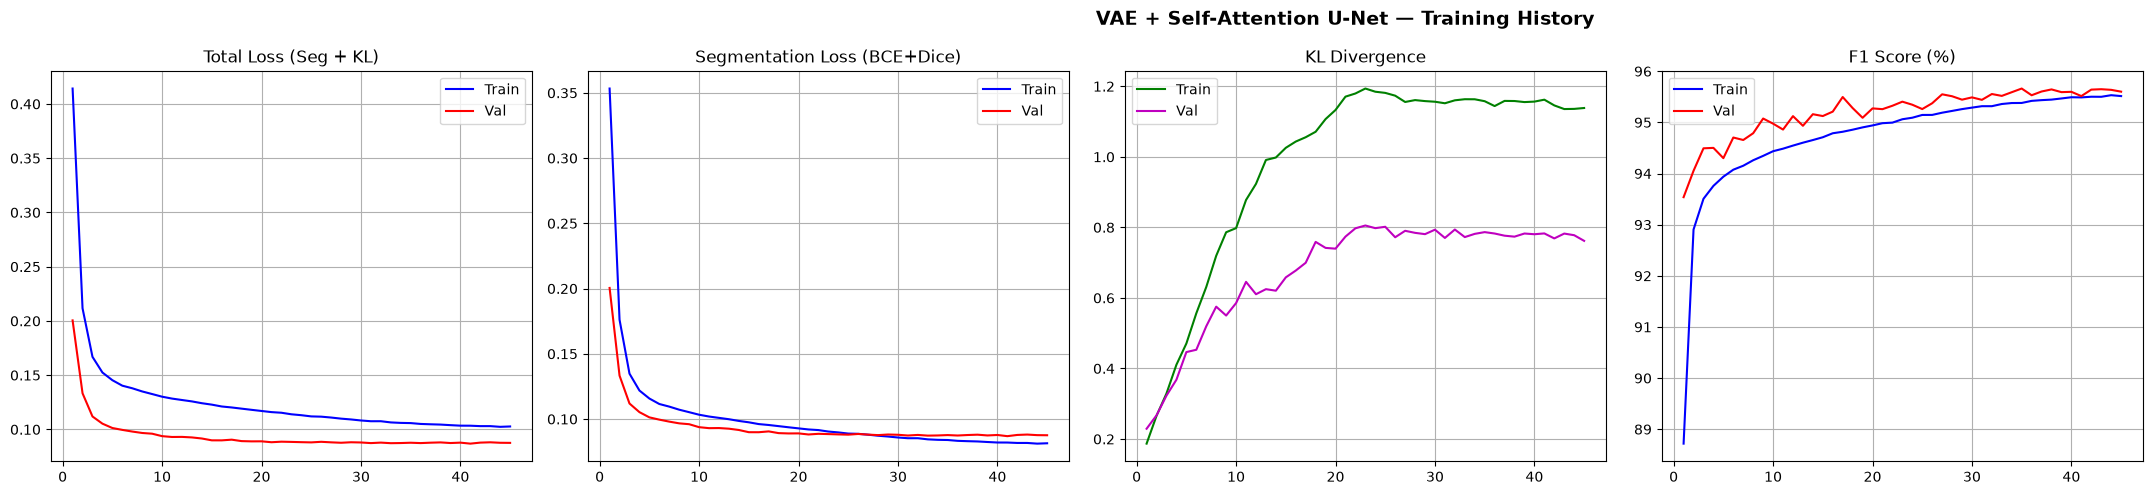

Training curves saved ✓


In [25]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 5, figsize=(27, 5))
fig.suptitle('VAE + Self-Attention U-Net — Training History', fontsize=14, fontweight='bold')

# Total Loss
axes[0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0].plot(ep, history['val_loss'],   'r-', label='Val')
axes[0].set_title('Total Loss (Seg + KL)'); axes[0].legend(); axes[0].grid(True)

# Segmentation Loss
axes[1].plot(ep, history['train_seg'], 'b-', label='Train')
axes[1].plot(ep, history['val_seg'],   'r-', label='Val')
axes[1].set_title('Segmentation Loss (BCE+Dice)'); axes[1].legend(); axes[1].grid(True)

# KL Loss
axes[2].plot(ep, history['train_kl'], 'g-', label='Train')
axes[2].plot(ep, history['val_kl'],   'm-', label='Val')
axes[2].set_title('KL Divergence'); axes[2].legend(); axes[2].grid(True)

# F1 Score
axes[3].plot(ep, history['train_f1'], 'b-', label='Train')
axes[3].plot(ep, history['val_f1'],   'r-', label='Val')
axes[3].set_title('F1 Score (%)'); axes[3].legend(); axes[3].grid(True)

# IoU Score
if 'train_iou' in history and history['train_iou']:
    axes[4].plot(ep, history['train_iou'], 'b-', label='Train')
    axes[4].plot(ep, history['val_iou'],   'r-', label='Val')
    axes[4].set_title('IoU Score (%)'); axes[4].legend(); axes[4].grid(True)
else:
    axes[4].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(cfg.CHECKPOINT, 'training_curves.png'), dpi=150)
plt.show()
print("Training curves saved ✓")


## 9. Test Evaluation

In [26]:
# ── Load best model ───────────────────────────────────────────────
ckpt = torch.load(best_ckpt, map_location=cfg.DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best model  (epoch {ckpt["epoch"]}, '
      f'val F1={ckpt["best_f1"]:.2f}%)')

# ── Helper: evaluate one loader ───────────────────────────────────
@torch.no_grad()
def eval_loader(loader, tag='Test'):
    tp = fp = fn = tn = 0
    for imgs, masks, _ in tqdm(loader, desc=tag, leave=False):
        imgs  = imgs.to(cfg.DEVICE, non_blocking=True)
        masks = masks.to(cfg.DEVICE, non_blocking=True)
        with autocast(enabled=cfg.USE_AMP):
            out = model(imgs)
        logits = out[0]
        pred = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
        tp += (pred * masks).sum().item()
        fp += (pred * (1 - masks)).sum().item()
        fn += ((1 - pred) * masks).sum().item()
        tn += ((1 - pred) * (1 - masks)).sum().item()
    eps = 1e-6
    precision = tp / (tp + fp + eps) * 100
    recall    = tp / (tp + fn + eps) * 100
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps) * 100
    acc       = (tp + tn) / (tp + fp + fn + tn + eps) * 100
    return dict(f1=f1, iou=iou, precision=precision, recall=recall, accuracy=acc)


# ── Overall test ──────────────────────────────────────────────────
overall = eval_loader(test_loader, 'Overall Test')
print()
print('=' * 58)
print('  OVERALL TEST RESULTS')
print('=' * 58)
for k, v in overall.items():
    print(f'  {k:12s}: {v:.2f}%')

# ── Per-subset breakdown ──────────────────────────────────────────
print()
print('=' * 58)
print('  PER-SUBSET BREAKDOWN')
print('=' * 58)
print(f"  {'Subset':14s} {'F1':>7} {'IoU':>7} {'Prec':>7} {'Rec':>7} {'Acc':>7}")
print('  ' + '-' * 50)
for subset, sl in subset_loaders.items():
    m = eval_loader(sl, subset)
    print(f"  {subset:14s} {m['f1']:7.2f} {m['iou']:7.2f} "
          f"{m['precision']:7.2f} {m['recall']:7.2f} {m['accuracy']:7.2f}")

# ── Unseen hold-out evaluation ────────────────────────────────────
if len(unseen_samples) > 0:
    print()
    print('=' * 58)
    print('  UNSEEN HOLD-OUT (6 images)')
    print('=' * 58)
    unseen_m = eval_loader(unseen_loader, 'Unseen')
    for k, v in unseen_m.items():
        print(f'  {k:12s}: {v:.2f}%')


Loaded best model  (epoch 35, val F1=95.66%)


Overall Test:  54%|█████▍    | 49/91 [00:10<00:07,  5.32it/s]


  OVERALL TEST RESULTS
  f1          : 95.59%
  iou         : 91.55%
  precision   : 93.33%
  recall      : 97.97%
  accuracy    : 98.81%

  PER-SUBSET BREAKDOWN
  Subset              F1     IoU    Prec     Rec     Acc
  --------------------------------------------------


  fish_01          96.16   92.61   94.19   98.22   98.95


  fish_02          95.39   91.18   93.00   97.91   98.71


...

  fish_20          92.76   86.50   90.08   95.61   98.28


  fish_21          96.79   93.78   94.22   99.50   99.21


  fish_22          97.79   95.67   96.69   98.91   99.45


  fish_23          96.19   92.66   96.43   95.96   99.34

  UNSEEN HOLD-OUT (6 images)


  f1          : 95.46%
  iou         : 91.32%
  precision   : 93.12%
  recall      : 97.93%
  accuracy    : 98.78%


## 10. Qualitative Results

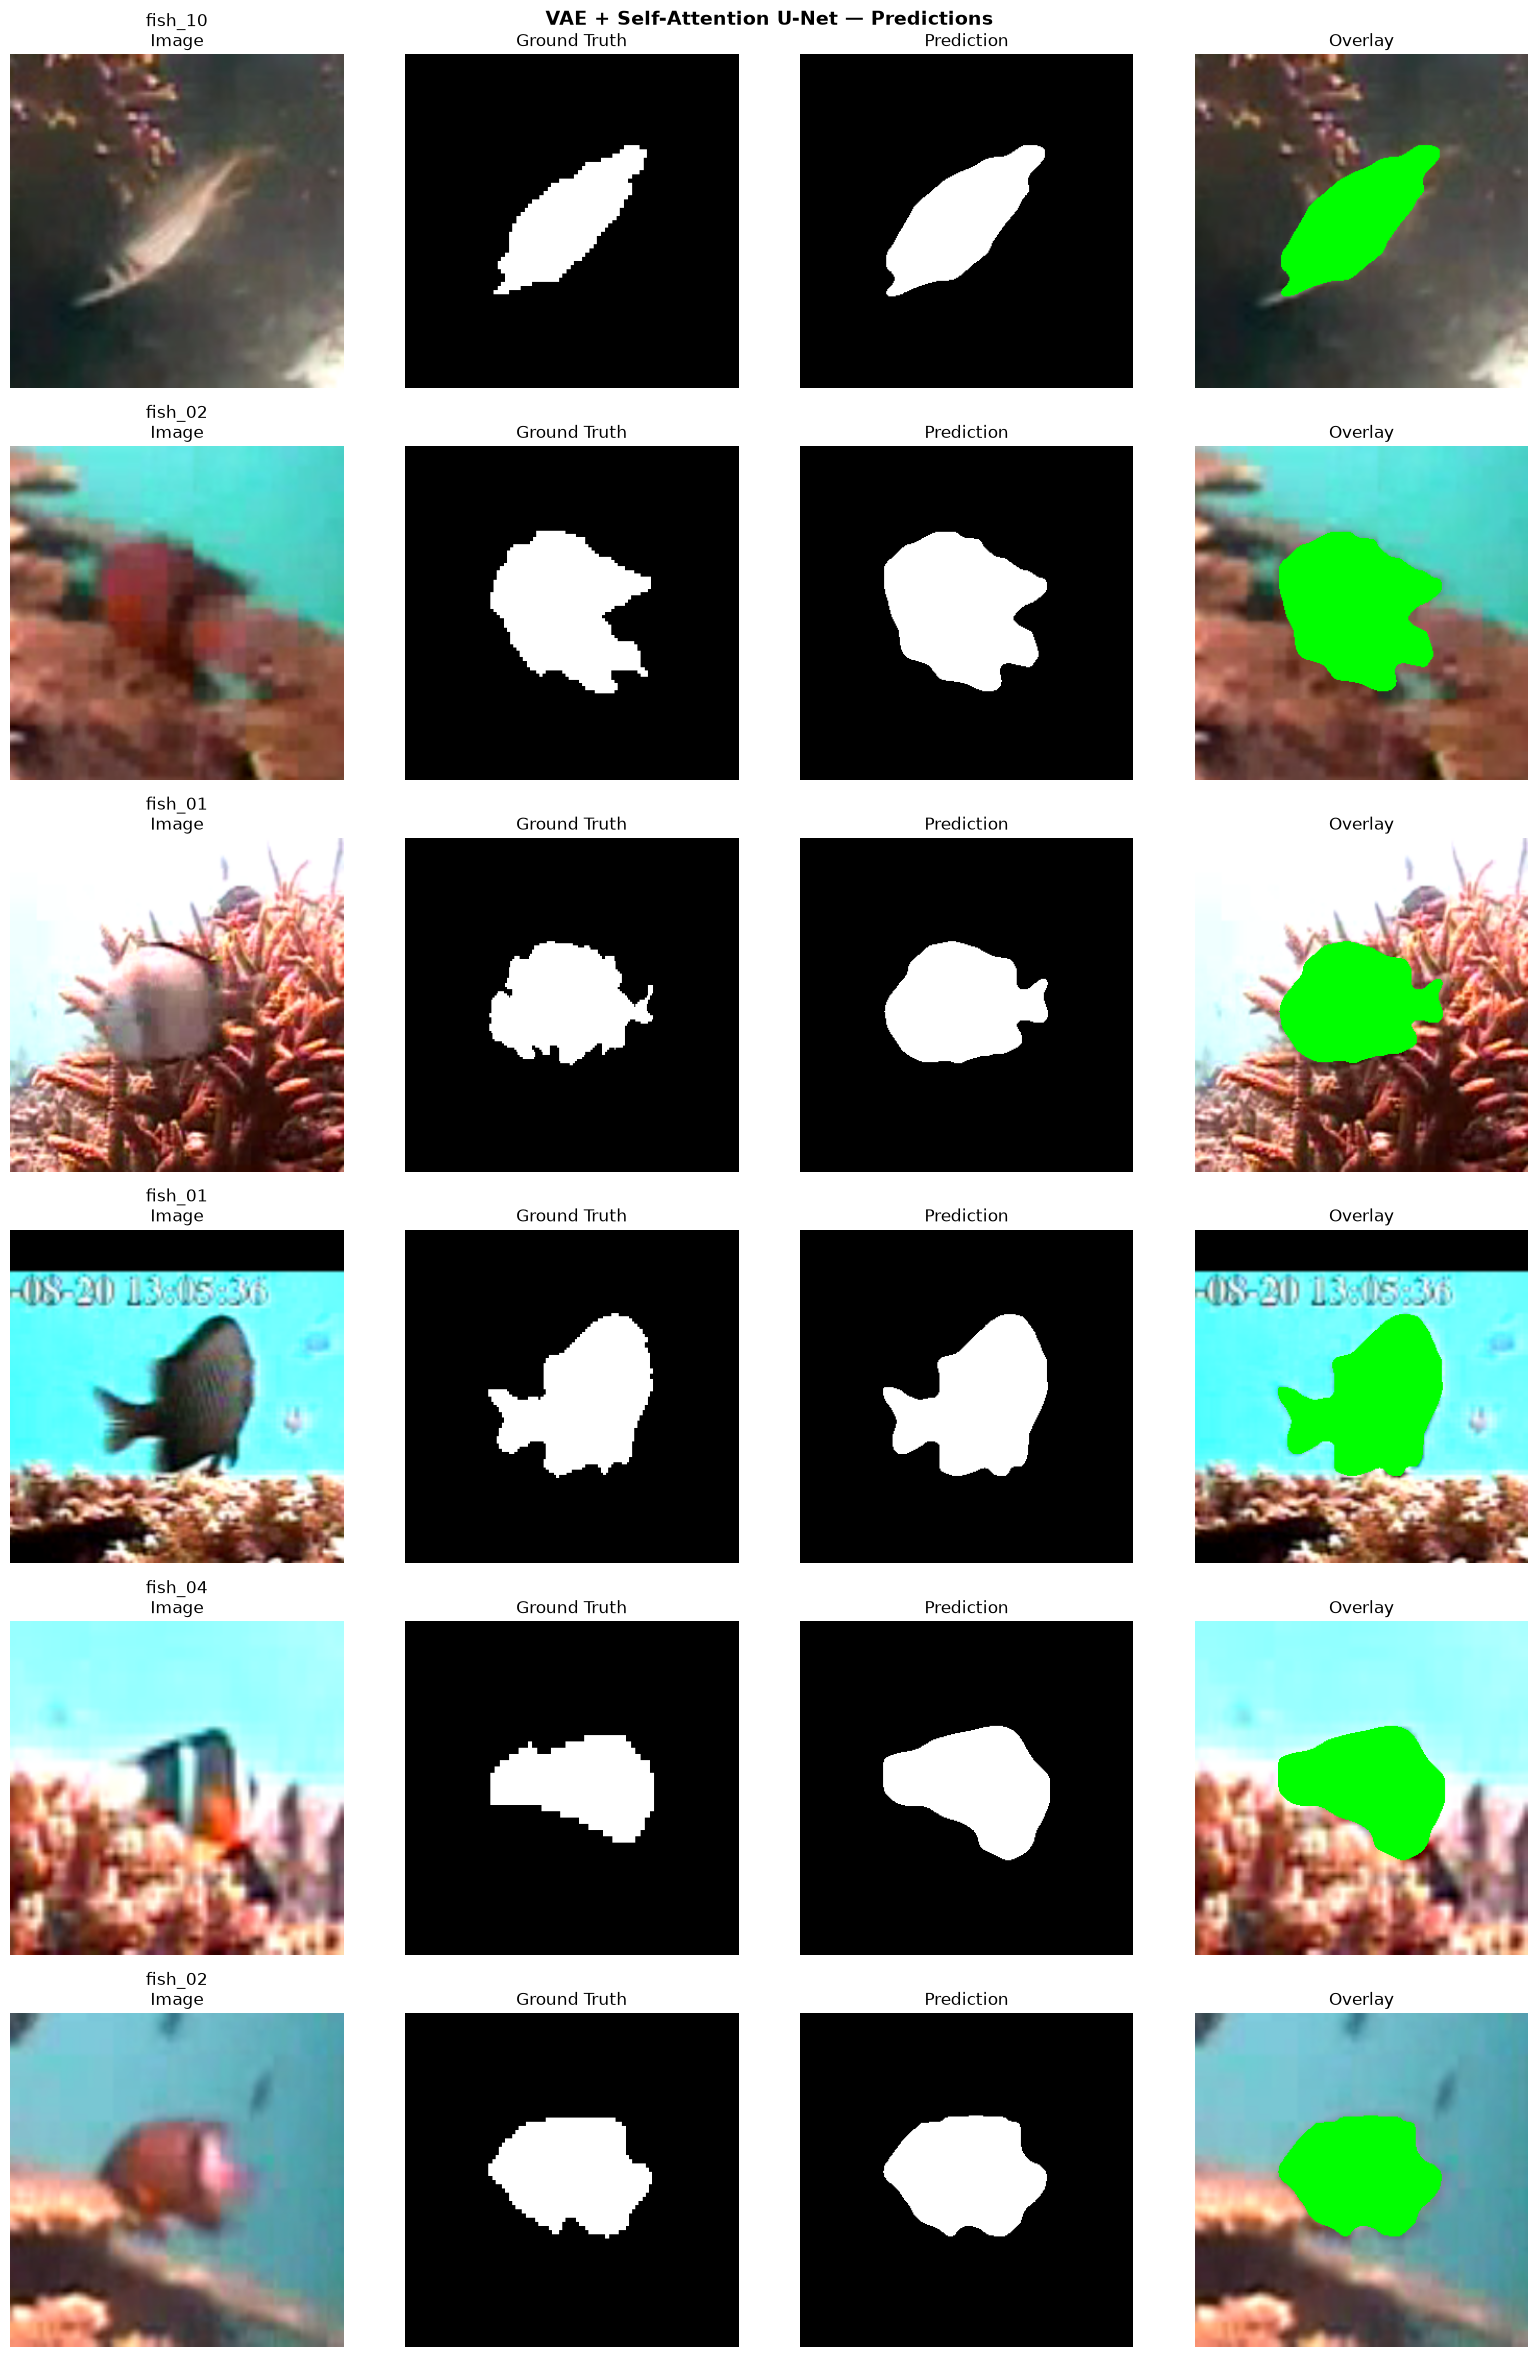

In [27]:
@torch.no_grad()
def visualise(model, samples, transform, device, n=6):
    model.eval()
    chosen = random.sample(samples, min(n, len(samples)))
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    fig.suptitle('VAE + Self-Attention U-Net — Predictions', fontsize=14, fontweight='bold')

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    for row, (img_p, mask_p, cat) in enumerate(chosen):
        img_raw  = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        mask_raw = (cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        out      = transform(image=img_raw, mask=mask_raw)
        inp      = out['image'].unsqueeze(0).to(device)

        with autocast(enabled=cfg.USE_AMP):
            logit, _, _ = model(inp)
        pred = (torch.sigmoid(logit.squeeze()) > 0.5).cpu().numpy()
        img_show = (out['image'] * std + mean).permute(1,2,0).clamp(0,1).numpy()

        axes[row,0].imshow(img_show);           axes[row,0].set_title(f'{cat}\nImage')
        axes[row,1].imshow(out['mask'], cmap='gray'); axes[row,1].set_title('Ground Truth')
        axes[row,2].imshow(pred, cmap='gray');  axes[row,2].set_title('Prediction')
        overlay = img_show.copy()
        overlay[pred.astype(bool)] = [0,1,0]
        axes[row,3].imshow(overlay);            axes[row,3].set_title('Overlay')
        for ax in axes[row]: ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.CHECKPOINT, 'qualitative.png'), dpi=150)
    plt.show()

visualise(model, unseen_samples + test_samples, val_tf, cfg.DEVICE, n=6)


## 11. VAE Latent Space Visualisation

In [28]:
from sklearn.decomposition import PCA

# Collect μ vectors for all test samples (mean-pool spatial dims → 1D per image)
model.eval()
all_mu, all_cats = [], []

with torch.no_grad():
    for imgs, masks, cats in tqdm(test_loader, desc='Latent'):
        imgs = imgs.to(cfg.DEVICE)
        with autocast(enabled=cfg.USE_AMP):
            _, mu, _ = model(imgs)
        # Mean-pool spatial (8×8) → (B, latent_dim)
        mu_flat = mu.mean(dim=(2, 3)).cpu().numpy()
        all_mu.extend(mu_flat)
        all_cats.extend(cats)

all_mu = np.array(all_mu)

# PCA to 2D for plotting
pca  = PCA(n_components=2)
mu2d = pca.fit_transform(all_mu)

# Plot top-10 most common categories
top_cats = [c for c, _ in Counter(all_cats).most_common(10)]
cmap     = plt.cm.get_cmap('tab10', len(top_cats))

fig, ax = plt.subplots(figsize=(10, 8))
for i, cat in enumerate(top_cats):
    idx = [j for j, c in enumerate(all_cats) if c == cat]
    ax.scatter(mu2d[idx, 0], mu2d[idx, 1], s=20, alpha=0.6,
               color=cmap(i), label=cat)

ax.set_title('VAE Latent Space (μ) — PCA 2D\n'
             f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(cfg.CHECKPOINT, 'latent_space.png'), dpi=150)
plt.show()
print("\nWell-separated clusters = VAE learned meaningful fish-type representations ✓")


Latent:   0%|          | 0/91 [00:00<?, ?it/s]

Latent: 100%|██████████| 91/91 [00:19<00:00,  4.68it/s]


AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

## 12. Save Results

In [32]:
summary = {
    'model'       : 'VAE-SA-UNet-ConvNeXt-AttentionGate-v3',
    'config'      : vars(cfg),
    'test_overall': overall,
    'per_category': m,
}

out_path = os.path.join(cfg.CHECKPOINT, 'results.json')
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Results saved → {out_path}")
print(f"Best model   → {best_ckpt}")
print(f"\n✅ All done!")


Results saved → ./checkpoints/results.json
Best model   → ./checkpoints/best_vae_sa_unet.pth

✅ All done!
